In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Locate the repository root regardless of where Jupyter starts.
ROOT = Path.cwd().resolve()

while ROOT != ROOT.parent and not (ROOT / "data_labeling").exists():
    ROOT = ROOT.parent

LABEL_DIR = ROOT / "data_labeling" / "data_labels"

OLD_LABELS = LABEL_DIR / "labels_2010_2018.csv"
NEW_LABELS = LABEL_DIR / "labels_2019_2026_july.csv"

print("Repository:", ROOT)
print("2010–2018 file exists:", OLD_LABELS.exists())
print("2019–2026 file exists:", NEW_LABELS.exists())

Repository: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-
2010–2018 file exists: True
2019–2026 file exists: True


In [3]:
old_df = pd.read_csv(OLD_LABELS)
new_df = pd.read_csv(NEW_LABELS)


In [4]:
old_df["source_file"] = "2010_2018"
new_df["source_file"] = "2019_2026"

In [5]:
df = pd.concat([old_df, new_df], ignore_index=True)

In [6]:
print("2010–2018 rows:", len(old_df))
print("2019–July 2026 rows:", len(new_df))
print("Combined rows:", len(df))


2010–2018 rows: 63285
2019–July 2026 rows: 64808
Combined rows: 128093


In [7]:
df.head()

,label,goes_class,fl_lon,fl_lat,rest_fl,rest_lon,rest_lat,source_file
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,NF,unk,unk,NaN,NaN,NaN,2010_2018
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018


In [8]:
df["datetime"] = pd.to_datetime(
    df["label"].str.extract(
        r"HMI\.m(\d{4}\.\d{2}\.\d{2}_\d{2}\.\d{2}\.\d{2})"
    )[0],
    format="%Y.%m.%d_%H.%M.%S",
    errors="coerce",
)

In [9]:
df.head()

,label,goes_class,fl_lon,fl_lat,rest_fl,rest_lon,rest_lat,source_file,datetime
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,NF,unk,unk,NaN,NaN,NaN,2010_2018,2010-12-06 07:00:00
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 08:00:00
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 09:00:00
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 10:00:00
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 11:00:00


In [10]:
df["year"] = df["datetime"].dt.year

In [11]:
df.head()

,label,goes_class,fl_lon,fl_lat,rest_fl,rest_lon,rest_lat,source_file,datetime,year
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,NF,unk,unk,NaN,NaN,NaN,2010_2018,2010-12-06 07:00:00,2010
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 08:00:00,2010
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 09:00:00,2010
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 10:00:00,2010
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 11:00:00,2010


In [12]:
print("Missing parsed datetimes:", df["datetime"].isna().sum())
print("First datetime:", df["datetime"].min())
print("Last datetime:", df["datetime"].max())

Missing parsed datetimes: 0
First datetime: 2010-12-06 07:00:00
Last datetime: 2026-07-31 23:00:00


In [13]:
print("Total rows:", len(df))
print("Duplicate image labels:", df["label"].duplicated().sum())
print("Missing GOES classes:", df["goes_class"].isna().sum())
print()

print("GOES classes:")
print(df["goes_class"].astype(str).str[0].value_counts())

Total rows: 128093
Duplicate image labels: 0
Missing GOES classes: 0

GOES classes:
goes_class
C    48534
B    24517
N    23555
M    22288
A     6558
X     2641
Name: count, dtype: int64


In [14]:
df["class_letter"] = (
    df["goes_class"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str[0]
)

In [15]:
df.head()

,label,goes_class,fl_lon,fl_lat,rest_fl,rest_lon,rest_lat,source_file,datetime,year,class_letter
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,NF,unk,unk,NaN,NaN,NaN,2010_2018,2010-12-06 07:00:00,2010,N
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 08:00:00,2010,B
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 09:00:00,2010,B
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 10:00:00,2010,B
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 11:00:00,2010,B


In [16]:
# M and X are positive flare samples.
df["target"] = df["class_letter"].isin(["M", "X"]).astype(int)
df.head()

,label,goes_class,fl_lon,fl_lat,rest_fl,rest_lon,rest_lat,source_file,datetime,year,class_letter,target
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,NF,unk,unk,NaN,NaN,NaN,2010_2018,2010-12-06 07:00:00,2010,N,0
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 08:00:00,2010,B,0
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 09:00:00,2010,B,0
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 10:00:00,2010,B,0
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 11:00:00,2010,B,0


In [17]:
df["binary_class"] = df["target"].map({
    0: "NF",
    1: "FL",
})

df.head()

,label,goes_class,fl_lon,fl_lat,rest_fl,rest_lon,rest_lat,source_file,datetime,year,class_letter,target,binary_class
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,NF,unk,unk,NaN,NaN,NaN,2010_2018,2010-12-06 07:00:00,2010,N,0,NF
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 08:00:00,2010,B,0,NF
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 09:00:00,2010,B,0,NF
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 10:00:00,2010,B,0,NF
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,B1.9,-38.5479308163,16.0,['B1.9'],['-38.5479308163'],['16.0'],2010_2018,2010-12-06 11:00:00,2010,B,0,NF


In [18]:
print(df["binary_class"].value_counts())
print()
print(df["binary_class"].value_counts(normalize=True).mul(100).round(2))

binary_class
NF    103164
FL     24929
Name: count, dtype: int64

binary_class
NF    80.54
FL    19.46
Name: proportion, dtype: float64


In [19]:
yearly = (
    df.groupby("year")
    .agg(
        total=("label", "size"),
        FL=("target", "sum"),
    )
    .reset_index()
)

yearly["NF"] = yearly["total"] - yearly["FL"]
yearly["FL_percent"] = 100 * yearly["FL"] / yearly["total"]
yearly["NF_to_FL"] = yearly["NF"] / yearly["FL"].replace(0, np.nan)

yearly = yearly[
    ["year", "total", "FL", "NF", "FL_percent", "NF_to_FL"]
]

yearly.round({
    "FL_percent": 2,
    "NF_to_FL": 2,
})

,year,total,FL,NF,FL_percent,NF_to_FL
0,2010,562,0,562,0.00,NaN
1,2011,6528,1235,5293,18.92,4.29
2,2012,6516,1358,5158,20.84,3.80
3,2013,7656,1436,6220,18.76,4.33
4,2014,8405,2702,5703,32.15,2.11
5,2015,8511,1664,6847,19.55,4.11
6,2016,8337,250,8087,3.00,32.35
7,2017,8377,330,8047,3.94,24.38
8,2018,8393,0,8393,0.00,NaN
9,2019,8421,24,8397,0.29,349.88


In [20]:
goes_by_year = pd.crosstab(
    df["year"],
    df["class_letter"],
)

for column in ["A", "B", "C", "M", "X", "N"]:
    if column not in goes_by_year.columns:
        goes_by_year[column] = 0

goes_by_year

class_letter,A,B,C,M,N,X
year,,,,,,
2010,0,298,54,0,210,0
2011,0,1878,3218,1075,197,160
2012,0,1190,3822,1289,146,69
2013,0,1580,4252,1234,388,202
2014,0,483,5077,2373,143,329
2015,0,1459,4857,1617,531,47
2016,0,4250,2304,250,1533,0
2017,0,3359,1225,273,3463,57
2018,766,1728,275,0,5624,0


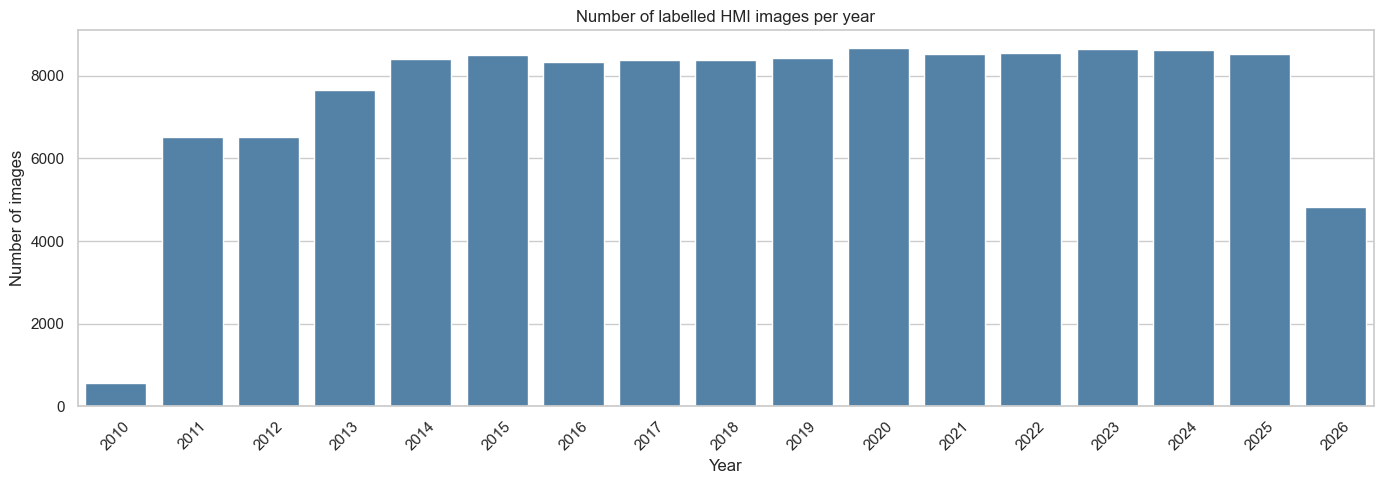

In [21]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=yearly,
    x="year",
    y="total",
    color="steelblue",
)

plt.title("Number of labelled HMI images per year")
plt.xlabel("Year")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Remember:
- 2010 is incomplete because your images begin in December.
- 2026 is incomplete because the data ends in July.

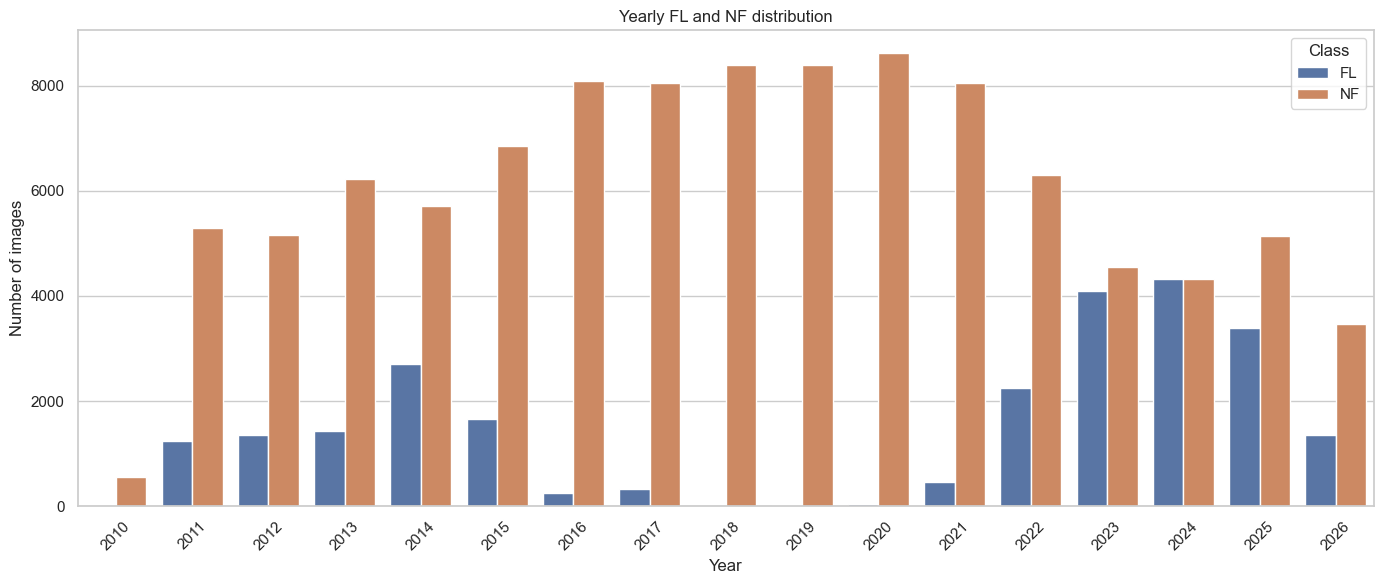

In [22]:
plot_counts = yearly.melt(
    id_vars="year",
    value_vars=["FL", "NF"],
    var_name="Class",
    value_name="Count",
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=plot_counts,
    x="year",
    y="Count",
    hue="Class",
)

plt.title("Yearly FL and NF distribution")
plt.xlabel("Year")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

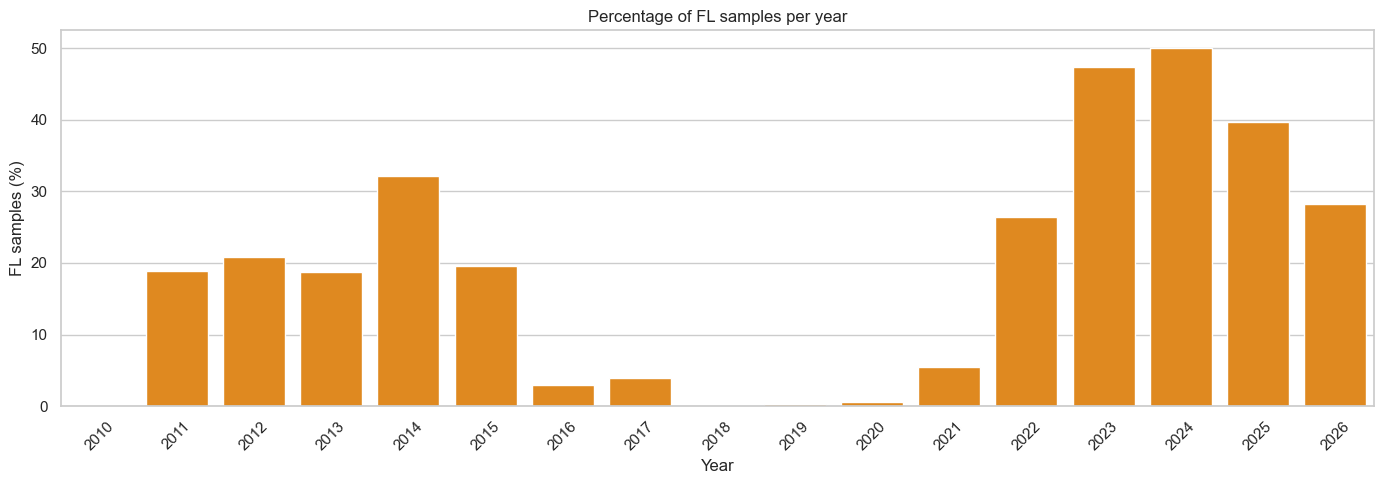

In [23]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=yearly,
    x="year",
    y="FL_percent",
    color="darkorange",
)

# plt.axvline(12.5, color="black")

plt.title("Percentage of FL samples per year")
plt.xlabel("Year")
plt.ylabel("FL samples (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
def summarize_period(data, name, start_year, end_year):
    part = data[
        data["year"].between(start_year, end_year)
    ]

    total = len(part)
    fl = int(part["target"].sum())
    nf = total - fl

    return {
        "period": name,
        "years": f"{start_year}-{end_year}",
        "total": total,
        "FL": fl,
        "NF": nf,
        "FL_percent": 100 * fl / total if total else np.nan,
        "NF_to_FL": nf / fl if fl else np.nan,
    }

In [25]:
proposed_summary = pd.DataFrame([
    summarize_period(df, "Stage 1", 2010, 2014),
    summarize_period(df, "Stage 2", 2015, 2018),
    summarize_period(df, "Stage 3", 2019, 2020),
    summarize_period(df, "Stage 4", 2021, 2022),
    summarize_period(df, "Validation", 2023, 2024),
    summarize_period(df, "Test", 2025, 2026),
])

proposed_summary.round({
    "FL_percent": 2,
    "NF_to_FL": 2,
})

,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Stage 1,2010-2014,29667,6731,22936,22.69,3.41
1,Stage 2,2015-2018,33618,2244,31374,6.67,13.98
2,Stage 3,2019-2020,17088,72,17016,0.42,236.33
3,Stage 4,2021-2022,17076,2729,14347,15.98,5.26
4,Validation,2023-2024,17279,8408,8871,48.66,1.06
5,Test,2025-2026,13365,4745,8620,35.50,1.82


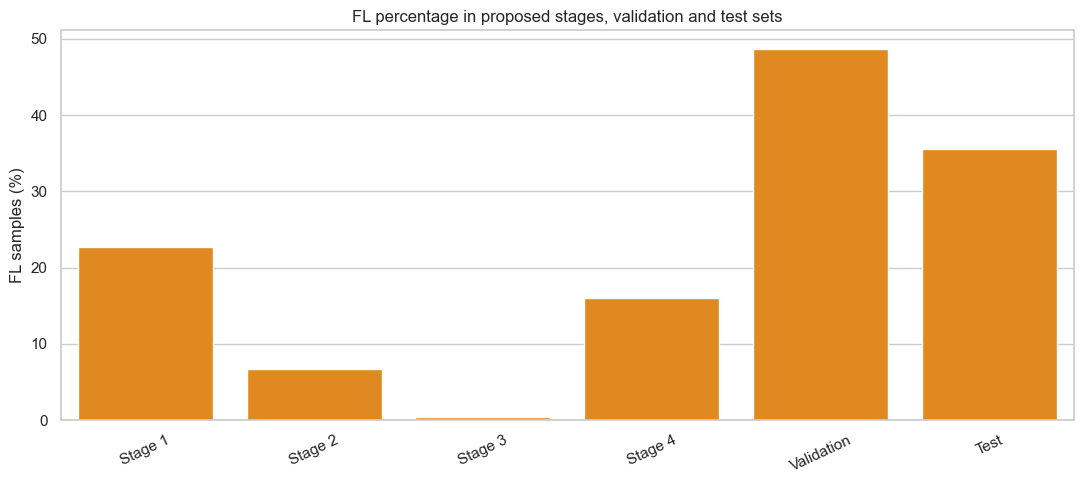

In [26]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=proposed_summary,
    x="period",
    y="FL_percent",
    color="darkorange",
)

plt.title("FL percentage in proposed stages, validation and test sets")
plt.xlabel("")
plt.ylabel("FL samples (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [27]:
training_years = list(range(2010, 2023))
candidate_results = []

# Three boundaries create four chronological stages.
for cut1, cut2, cut3 in combinations(range(2010, 2022), 3):
    periods = [
        (2010, cut1),
        (cut1 + 1, cut2),
        (cut2 + 1, cut3),
        (cut3 + 1, 2022),
    ]

    # Require every stage to cover at least two calendar years.
    if any(end - start + 1 < 2 for start, end in periods):
        continue

    summaries = [
        summarize_period(df, f"Stage {i + 1}", start, end)
        for i, (start, end) in enumerate(periods)
    ]

    totals = np.array([item["total"] for item in summaries], dtype=float)
    ratios = np.array([item["NF_to_FL"] for item in summaries], dtype=float)

    if np.isnan(ratios).any():
        continue

    # Lower values mean the stages are more similar.
    size_variation = totals.std() / totals.mean()
    ratio_variation = ratios.std() / ratios.mean()

    candidate_results.append({
        "stage_1": f"{periods[0][0]}-{periods[0][1]}",
        "stage_2": f"{periods[1][0]}-{periods[1][1]}",
        "stage_3": f"{periods[2][0]}-{periods[2][1]}",
        "stage_4": f"{periods[3][0]}-{periods[3][1]}",
        "size_variation": size_variation,
        "imbalance_variation": ratio_variation,
        "combined_score": size_variation + ratio_variation,
    })

candidates = pd.DataFrame(candidate_results)

candidates.sort_values("combined_score").head(15).round(3)

,stage_1,stage_2,stage_3,stage_4,size_variation,imbalance_variation,combined_score
23,2010-2012,2013-2014,2015-2018,2019-2022,0.393,0.575,0.968
3,2010-2011,2012-2013,2014-2018,2019-2022,0.584,0.408,0.992
8,2010-2011,2012-2014,2015-2018,2019-2022,0.451,0.543,0.994
4,2010-2011,2012-2013,2014-2019,2020-2022,0.676,0.333,1.009
22,2010-2012,2013-2014,2015-2017,2018-2022,0.466,0.579,1.046
7,2010-2011,2012-2014,2015-2017,2018-2022,0.516,0.547,1.063
24,2010-2012,2013-2014,2015-2019,2020-2022,0.458,0.695,1.154
2,2010-2011,2012-2013,2014-2017,2018-2022,0.587,0.567,1.154
9,2010-2011,2012-2014,2015-2019,2020-2022,0.509,0.664,1.173
36,2010-2013,2014-2015,2016-2017,2018-2022,0.438,0.811,1.249


In [28]:
candidate_number = 0

chosen = (
    candidates
    .sort_values("combined_score")
    .iloc[candidate_number]
)

periods = [
    tuple(map(int, chosen["stage_1"].split("-"))),
    tuple(map(int, chosen["stage_2"].split("-"))),
    tuple(map(int, chosen["stage_3"].split("-"))),
    tuple(map(int, chosen["stage_4"].split("-"))),
]

candidate_summary = pd.DataFrame([
    summarize_period(df, f"Stage {i + 1}", start, end)
    for i, (start, end) in enumerate(periods)
])

candidate_summary.round({
    "FL_percent": 2,
    "NF_to_FL": 2,
})

,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Stage 1,2010-2012,13606,2593,11013,19.06,4.25
1,Stage 2,2013-2014,16061,4138,11923,25.76,2.88
2,Stage 3,2015-2018,33618,2244,31374,6.67,13.98
3,Stage 4,2019-2022,34164,2801,31363,8.20,11.20


In [29]:
future_sets = pd.DataFrame([
    summarize_period(df, "Validation", 2023, 2024),
    summarize_period(df, "Test", 2025, 2026),
])

future_sets.round({
    "FL_percent": 2,
    "NF_to_FL": 2,
})

,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Validation,2023-2024,17279,8408,8871,48.66,1.06
1,Test,2025-2026,13365,4745,8620,35.50,1.82


In [ ]:


candidate_number = 0

chosen = (
    candidates
    .sort_values("combined_score")
    .iloc[candidate_number]
)

periods = [
    tuple(map(int, chosen["stage_1"].split("-"))),
    tuple(map(int, chosen["stage_2"].split("-"))),
    tuple(map(int, chosen["stage_3"].split("-"))),
    tuple(map(int, chosen["stage_4"].split("-"))),
]

candidate_summary = pd.DataFrame([
    summarize_period(df, f"Stage {i + 1}", start, end)
    for i, (start, end) in enumerate(periods)
])

candidate_summary.round({
    "FL_percent": 2,
    "NF_to_FL": 2,
})

,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Stage 1,2010-2011,7090,1235,5855,17.42,4.74
1,Stage 2,2012-2013,14172,2794,11378,19.71,4.07
2,Stage 3,2014-2019,50444,4970,45474,9.85,9.15
3,Stage 4,2020-2022,25743,2777,22966,10.79,8.27
